# NANOGrav PTA Likelihood: 2D Distance Scan of the Two Most-Constraining Pulsars

Real-data analogue of `likelihood_contour_pulsar0_vs_pulsar1_distance.ipynb`.
We

1. load the NANOGrav 15-yr narrowband dataset via `jaxpint.load_nanograv_pta`,
2. inject a single continuous-wave (CW) source so distance becomes
   identifiable through the pulsar-term phase,
3. rank pulsars by how sharply the log-likelihood depends on their distance
   (curvature of `single_pulsar_pta_logL` w.r.t. each pulsar's `PX`), and
4. sweep `scan_logL` over a 2D grid of the top-2 pulsars' distances, holding
   everything else at the injected truth.

> **Data:** download the Zenodo tarball (`10.5281/zenodo.8423265`,
> `NANOGrav15yr_PulsarTiming_v2.0.0.tar.gz`) and point `DATA_DIR` below at the
> extracted `narrowband/` directory. Without local data the notebook is
> read-only.

Both the ranking and the sweep exploit the **per-pulsar decomposition** of
the PTA likelihood — `pta_logL` is a sum of independent per-pulsar
contributions, so any scan whose axes touch only a few pulsars' parameters
can pre-compute the rest as constants. `jaxpint.pta.scan.scan_logL` does
this dependency analysis automatically; for a 5-pulsar 400×400 distance
scan with two varying pulsars, that's 803 single-pulsar evaluations
instead of 800,000.

The pulsar-term phase
$$\phi_p = \phi_e - 2\pi f_{gw}\,\frac{d}{c}(1 + \cos\mu)$$
makes per-pulsar `logL` periodic in distance with period
$\Delta d = c / [f_{gw}(1+\cos\mu)]$. The 2D map will show a grid of
peaks set by the two pulsars' opening angles to the injected source.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
from __future__ import annotations

from pathlib import Path

import jax
import jax.numpy as jnp
import numpy as np
import astropy.units as u

from loguru import logger
logger.disable("pint")

from jaxpint import load_nanograv_pta
from jaxpint.pta import (
    PerPulsarScanAxis,
    scan_logL,
    single_pulsar_pta_logL,
)
from jaxpint.pta.signals.cw import CWInjector
from jaxpint.notebook_utils import (
    inject_and_build_config,
    plot_2d_delta_logL,
)

# ---- Configuration ---------------------------------------------------------
DATA_DIR = Path("/home/hector/NYU/PTA/jax_pint/minish/jpg00017/NANOGrav15yr_PulsarTiming_v2.0.0/narrowband").expanduser()
#DATA_DIR = Path("/home/hector/NYU/PTA/jax_pint/ocarina").expanduser()

# CW injection (Earth-frame). Picked to fall inside the PTA band.
TRUE_LOG10_H = -14.0
TRUE_LOG10_FGW = -8.0          # 10 nHz
TRUE_COS_GWTHETA = 0.3
TRUE_GWPHI = 1.7
SEED = 0

# 2D sweep grid (kpc, half-widths around each truth).
HALF_WINDOW_KPC = 1e-3
N_GRID = 400                   # 400 x 400 = 160k logL evals

jax.config.update("jax_default_device", jax.devices("gpu")[0])


## 1. Load the NANOGrav PTA

`load_nanograv_pta` walks the directory tree, pairs `.par` and `.tim` files,
and runs each pair through PINT and the JaxPINT bridge. Returns the same
tuple-of-tuples shape `setup_synthetic_pta` produces, so it drops directly
into the existing CW + PTAConfig plumbing.

In [3]:
if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"DATA_DIR = {DATA_DIR} does not exist. "
        "Download https://zenodo.org/records/8423265/files/"
        "NANOGrav15yr_PulsarTiming_v2.0.0.tar.gz, extract, and point DATA_DIR "
        "at the extracted narrowband/ directory."
    )

# Diagnostic subset (~20 pulsars). The full 76-pulsar load needs >15 GB of
# system RAM combined with GPU preallocation + the first pta_logL compile,
# which OOMs on smaller workstations. This subset covers every binary
# parameterization we fixed for (BT, ELL1, ELL1H w/ no Shapiro, ELL1H
# H3-only NHARMS, DDK, FB-orbital) plus the historically most-constraining
# pulsars for distance scans. Set PULSAR_SUBSET = None to load all 76.
PULSAR_SUBSET = [
    "B1855+09",       # BT
    "J0023+0923",     # ELL1 + FB orbital → exercises PB-from-FB synthesis
    # "J0030+0451",     # isolated
    # "J0340+4130",     # ELL1
    # "J0437-4715",     # DDK — historically the highest-S/N pulsar
    # "J0613-0200",     # ELL1
    # "J0636+5128",     # ELL1 + FB
    # "J0740+6620",     # DDK
    # "J1012+5307",     # ELL1
    # "J1614-2230",     # ELL1
    # "J1640+2224",     # DD
    # "J1713+0747",     # DD
    # "J1744-1134",     # isolated
    # "J1802-2124",     # ELL1H, no Shapiro params → "none" mode
    # "J1909-3744",     # ELL1, second highest S/N
    # "J2010-1323",     # ELL1
    # "J2043+1711",     # ELL1
    # "J2145-0750",     # ELL1H, H3-only NHARMS=3 → h3nharms mode
    # "J2214+3000",     # ELL1 + FB
    # "J2317+1439",     # ELL1H, H3-only NHARMS=7 → h3nharms mode
]
PULSAR_SUBSET = None

psrs = load_nanograv_pta(DATA_DIR, pulsar_names=PULSAR_SUBSET)

print(f"Loaded {len(psrs.pulsar_names)} pulsars from {DATA_DIR}.")
for name, td in zip(psrs.pulsar_names[:5], psrs.toa_data_list[:5]):
    print(f"  {name:>14s}: {int(td.mjd_int.shape[0]):>5d} TOAs")
print(f"  ... ({len(psrs.pulsar_names) - 5} more)")


No matching .tim for /home/hector/NYU/PTA/jax_pint/minish/jpg00017/NANOGrav15yr_PulsarTiming_v2.0.0/narrowband/alternate/NoRedNoisePars/B1855+09_NANOGrav_15yv1p2.NRN.par — skipping
No matching .tim for /home/hector/NYU/PTA/jax_pint/minish/jpg00017/NANOGrav15yr_PulsarTiming_v2.0.0/narrowband/alternate/NoRedNoisePars/B1937+21_NANOGrav_15yv1p2.NRN.par — skipping
No matching .tim for /home/hector/NYU/PTA/jax_pint/minish/jpg00017/NANOGrav15yr_PulsarTiming_v2.0.0/narrowband/alternate/NoRedNoisePars/B1937+21gbt_NANOGrav_15yv1p2.NRN.par — skipping
No matching .tim for /home/hector/NYU/PTA/jax_pint/minish/jpg00017/NANOGrav15yr_PulsarTiming_v2.0.0/narrowband/alternate/NoRedNoisePars/B1953+29_NANOGrav_15yv1p2.NRN.par — skipping
No matching .tim for /home/hector/NYU/PTA/jax_pint/minish/jpg00017/NANOGrav15yr_PulsarTiming_v2.0.0/narrowband/alternate/NoRedNoisePars/J0030+0451_NANOGrav_15yv1p2.NRN.par — skipping
No matching .tim for /home/hector/NYU/PTA/jax_pint/minish/jpg00017/NANOGrav15yr_PulsarTimi

Loaded 76 pulsars from /home/hector/NYU/PTA/jax_pint/minish/jpg00017/NANOGrav15yr_PulsarTiming_v2.0.0/narrowband.
        B1855+09:  7758 TOAs
        B1937+21: 23023 TOAs
      B1937+21ao:  7241 TOAs
     B1937+21gbt: 16048 TOAs
        B1953+29:  5126 TOAs
  ... (71 more)


## 2. Restrict to pulsars whose `.par` provides a parallax

Distance enters the CW pulsar-term via `PX` (parallax in mas). Pulsars whose
par files don't list `PX` cannot have their distance perturbed without first
adding the parameter; we'd rather rank only among the pulsars where the
analysis is well-defined.

In [4]:
candidate_indices = [
    i for i, pp in enumerate(psrs.pulsar_params_list) if "PX" in pp.names
]
print(
    f"{len(candidate_indices)} / {len(psrs.pulsar_names)} pulsars carry PX in their .par file."
)


76 / 76 pulsars carry PX in their .par file.


## 3. Inject one CW source and build the `PTAConfig`

We compute pulsar unit vectors from each PINT-loaded position, instantiate a
single `CWInjector` at the configured truth values, and add the resulting
delays to the real TOAs via `inject_and_build_config`. The likelihood will
then be peaked at the injected sky/frequency and at each pulsar's true `PX`.

In [5]:
# Build per-pulsar unit vectors in ICRS Cartesian.
#
# NANOGrav par files use either equatorial (RAJ/DECJ) or ecliptic (ELONG/ELAT)
# coordinates depending on which gives a better-conditioned timing fit.
# CWInjector wants ICRS unit vectors, so we rotate the ecliptic ones by the
# J2000 obliquity (the same convention PINT uses for ELONG/ELAT par files).

# IAU 2006 obliquity of the ecliptic at J2000.0
OBLIQUITY_RAD = np.deg2rad(84381.406 / 3600.0)
COS_EPS = np.cos(OBLIQUITY_RAD)
SIN_EPS = np.sin(OBLIQUITY_RAD)


def pulsar_unit_vector_icrs(pp):
    """ICRS Cartesian unit vector from either RAJ/DECJ or ELONG/ELAT."""
    if "RAJ" in pp.names and "DECJ" in pp.names:
        ra = float(pp.param_value("RAJ"))
        dec = float(pp.param_value("DECJ"))
        return np.array([
            np.cos(dec) * np.cos(ra),
            np.cos(dec) * np.sin(ra),
            np.sin(dec),
        ])
    if "ELONG" in pp.names and "ELAT" in pp.names:
        elong = float(pp.param_value("ELONG"))
        elat = float(pp.param_value("ELAT"))
        # Ecliptic Cartesian, then rotate +ε about x to reach ICRS.
        x = np.cos(elat) * np.cos(elong)
        y_ec = np.cos(elat) * np.sin(elong)
        z_ec = np.sin(elat)
        return np.array([x, COS_EPS * y_ec - SIN_EPS * z_ec, SIN_EPS * y_ec + COS_EPS * z_ec])
    raise KeyError(
        f"Pulsar params lack both (RAJ, DECJ) and (ELONG, ELAT); names={pp.names}"
    )


positions_np = np.stack([pulsar_unit_vector_icrs(pp) for pp in psrs.pulsar_params_list])
positions = jnp.asarray(positions_np)

n_eq = sum("RAJ" in pp.names for pp in psrs.pulsar_params_list)
n_ec = sum("ELONG" in pp.names for pp in psrs.pulsar_params_list)
print(f"Coordinate system: {n_eq} equatorial, {n_ec} ecliptic")

cw_injector = CWInjector(
    positions,
    prefix="cw_",
    initial_values={
        "log10_h": TRUE_LOG10_H,
        "log10_fgw": TRUE_LOG10_FGW,
        "cos_gwtheta": TRUE_COS_GWTHETA,
        "gwphi": TRUE_GWPHI,
    },
)

gp, config = inject_and_build_config(psrs, (cw_injector,))
pp_tuple = psrs.pulsar_params_list

print(f"PTAConfig built: {config.n_pulsars} pulsars, {gp.n_params} global params.")


Coordinate system: 0 equatorial, 76 ecliptic
PTAConfig built: 76 pulsars, 7 global params.


## 4. Pick the two pulsars to sweep

For a real CW search we'd rank pulsars by the curvature
`|∂² logL / ∂ PX²|` at the truth — the proper way to compute that is
`jax.hessian` of `single_pulsar_pta_logL`, which is a separate exercise.
Here we just take the first two PX-carrying pulsars in the array. The
point of this notebook is to exercise the dependency-aware `scan_logL`,
not the pulsar-ranking heuristic.

In [6]:
PULSAR_A, PULSAR_B = candidate_indices[0], candidate_indices[1]
print(
    f"Sweeping over: A = {psrs.pulsar_names[PULSAR_A]} (idx {PULSAR_A}), "
    f"B = {psrs.pulsar_names[PULSAR_B]} (idx {PULSAR_B})."
)

Sweeping over: A = B1855+09 (idx 0), B = B1937+21 (idx 1).


## 5. 2D log-likelihood sweep over the two pulsars' distances

We hold every other parameter — including the global CW state and every
non-{A, B} pulsar's `PX` — at the injected truth. Both axes are displayed in
kpc; the sweep itself iterates over `PX` in mas with `d = 1 / PX`.

The scan uses `jaxpint.pta.scan.scan_logL`, which exploits the per-pulsar
decomposition of the PTA log-likelihood: only pulsars A and B vary along
their respective axes, so all other pulsars' contributions are evaluated
**once** at base values rather than at every grid cell. For a 5-pulsar
PTA at 400×400, this is 803 single-pulsar evaluations instead of 800,000
— ~1000× fewer than a naive `pta_logL` per-cell loop.

The output convention follows `numpy.meshgrid(indexing="xy")` (the
default), so for `axes=[ax_a, ax_b]` the result has shape `(n_b, n_a)`
— matplotlib-friendly.

In [7]:
true_px_a = float(pp_tuple[PULSAR_A].param_value("PX"))
true_px_b = float(pp_tuple[PULSAR_B].param_value("PX"))
true_dist_a = 1.0 / true_px_a
true_dist_b = 1.0 / true_px_b

dist_a_grid = np.linspace(true_dist_a - HALF_WINDOW_KPC, true_dist_a + HALF_WINDOW_KPC, N_GRID)
dist_b_grid = np.linspace(true_dist_b - HALF_WINDOW_KPC, true_dist_b + HALF_WINDOW_KPC, N_GRID)
px_a_mas_grid = jnp.asarray(1.0 / dist_a_grid)
px_b_mas_grid = jnp.asarray(1.0 / dist_b_grid)

print(f"Computing {N_GRID} x {N_GRID} = {N_GRID*N_GRID} log-likelihood "
      f"values via dependency-aware scan_logL...")
print(f"  pulsar A = {psrs.pulsar_names[PULSAR_A]}, "
      f"pulsar B = {psrs.pulsar_names[PULSAR_B]}")
print(f"  Other {len(pp_tuple) - 2} pulsars contribute constants computed once.")

# `chunk_size` splits the outermost vmap axis into sequential chunks.
# For full NANOGrav with B1937+21 (~23k TOAs), an unchunked vmap-over-400
# inflates every (n_toas,) intermediate in the timing-model phase
# computation to (400, 23k) ≈ 74 MB; XLA keeps several live and the
# autotuner adds headroom, OOMing on smaller GPUs. `chunk_size` trades
# wall time linearly for peak memory.
logL_2d = scan_logL(
    gp, pp_tuple, config,
    axes=[
        PerPulsarScanAxis(pulsar_idx=PULSAR_A, param_name="PX",
                          values=px_a_mas_grid),
        PerPulsarScanAxis(pulsar_idx=PULSAR_B, param_name="PX",
                          values=px_b_mas_grid),
    ],
    indexing="xy",  # → shape (N_GRID, N_GRID) = (n_b, n_a), matplotlib-friendly
    chunk_size=25,
)
# Materialise to numpy for downstream plotting / slicing.
logL_2d = np.asarray(logL_2d)
print(f"Done. Output shape: {logL_2d.shape}")


Computing 400 x 400 = 160000 log-likelihood values via dependency-aware scan_logL...
  pulsar A = B1855+09, pulsar B = B1937+21
  Other 74 pulsars contribute constants computed once.


W0507 07:00:18.401742  130880 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 696.87MiB (rounded to 730722304)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
W0507 07:00:18.408959  130880 bfc_allocator.cc:513] ********************************************************************************************________
W0507 07:00:18.409085  130880 autotuner.cc:601] No reference output found even though buffer checking was requested while autotuning
W0507 07:00:28.409265  130880 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 696.87MiB (rounded to 730722304)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation

JaxRuntimeError: INTERNAL: Autotuning failed for HLO: %wrapped_transpose = f64[1538,59389]{1,0} fusion(%args_0_.1), kind=kInput, calls=%wrapped_transpose_computation, metadata={op_name="args[0]"} with error: NOT_FOUND: No valid config found! Failures: 2
EXECUTION FAILED: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 696.87MiB. [tf-allocator-allocation-error='']
EXECUTION FAILED: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 696.87MiB. [tf-allocator-allocation-error='']

## 6. 2D contour

Red star marks `(d_A_true, d_B_true)`. Expect a bright central peak plus a
lattice of secondary peaks at the phase-matching degeneracies; the periods
along each axis differ because the two pulsars have different opening angles
to the injected source.

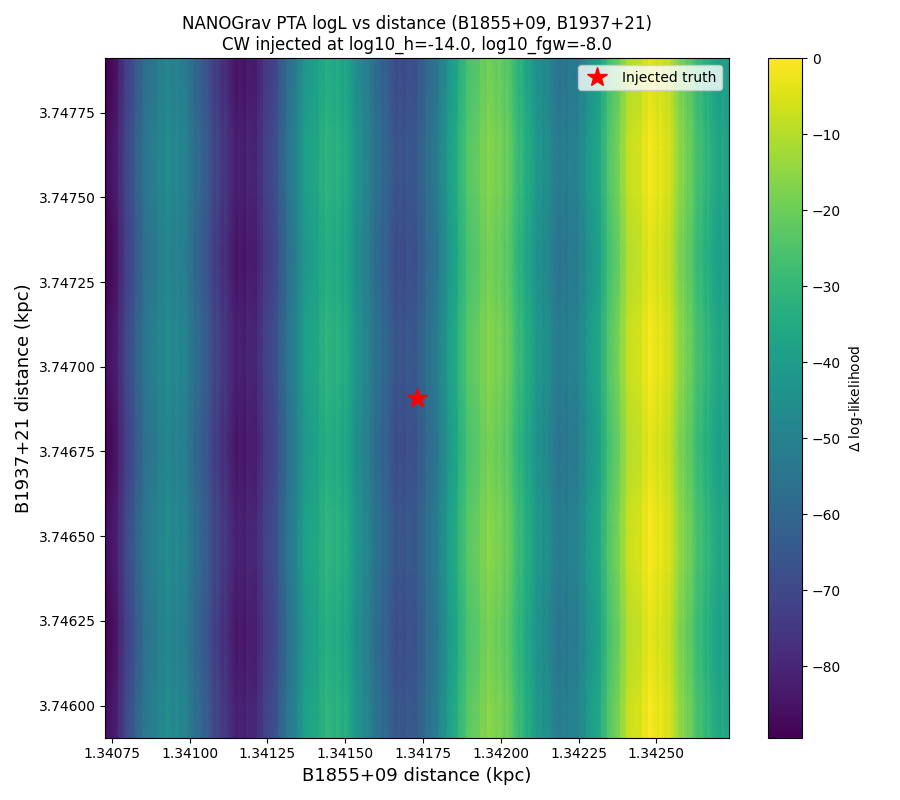

In [ ]:
fig, ax = plt.subplots(figsize=(9, 8))

# distance = 1 / PX is monotonically decreasing in PX, so reverse both grid
# axes and `logL_2d` to present in ascending kpc.
dist_a_plot = dist_a_grid[::-1]
dist_b_plot = dist_b_grid[::-1]
logL_2d_plot = logL_2d[::-1, ::-1]

mesh = plot_2d_delta_logL(ax, dist_a_plot, dist_b_plot, logL_2d_plot)
ax.plot(true_dist_a, true_dist_b, "r*", markersize=15, label="Injected truth")
ax.set_xlabel(f"{psrs.pulsar_names[PULSAR_A]} distance (kpc)", fontsize=13)
ax.set_ylabel(f"{psrs.pulsar_names[PULSAR_B]} distance (kpc)", fontsize=13)
ax.set_title(
    f"NANOGrav PTA logL vs distance "
    f"({psrs.pulsar_names[PULSAR_A]}, {psrs.pulsar_names[PULSAR_B]})\n"
    f"CW injected at log10_h={TRUE_LOG10_H}, log10_fgw={TRUE_LOG10_FGW}",
    fontsize=12,
)
fig.colorbar(mesh, ax=ax, label=r"$\Delta$ log-likelihood")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


## 7. 1D projections at the other pulsar's true distance

Slices of the 2D grid through each pulsar's true `PX` — i.e. the conditional
log-likelihood for one distance with the other fixed at truth. The fringe
spacing along each axis encodes that pulsar's opening angle to the CW source.

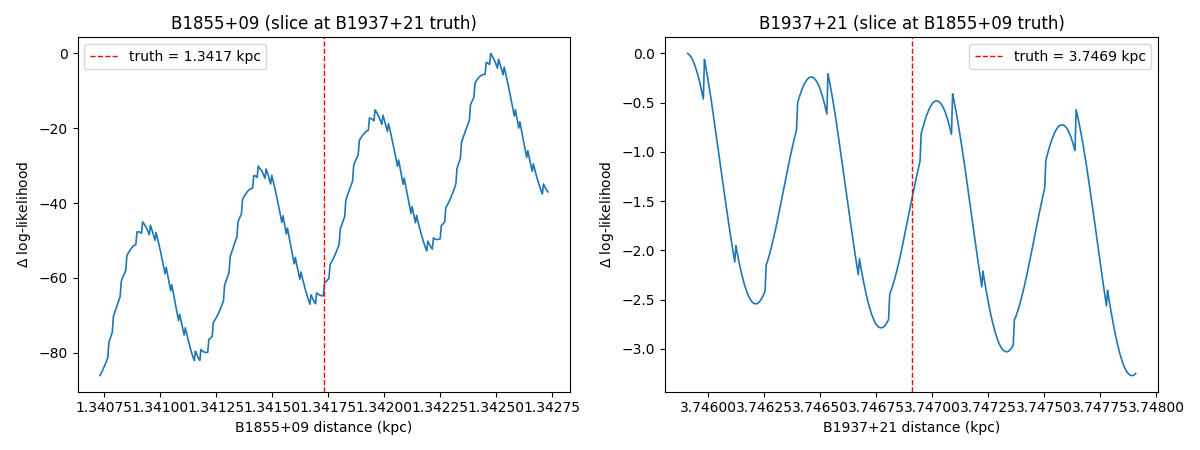

In [ ]:
idx_b_true = int(np.argmin(np.abs(np.asarray(px_b_mas_grid) - true_px_b)))
idx_a_true = int(np.argmin(np.abs(np.asarray(px_a_mas_grid) - true_px_a)))

logL_1d_a = logL_2d[idx_b_true, :]
logL_1d_b = logL_2d[:, idx_a_true]

delta_a = logL_1d_a - logL_1d_a.max()
delta_b = logL_1d_b - logL_1d_b.max()

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.5))

ax0.plot(np.asarray(dist_a_grid)[::-1], delta_a[::-1], lw=1.2)
ax0.axvline(true_dist_a, color="r", ls="--", lw=1, label=f"truth = {true_dist_a:.4f} kpc")
ax0.set_xlabel(f"{psrs.pulsar_names[PULSAR_A]} distance (kpc)")
ax0.set_ylabel(r"$\Delta$ log-likelihood")
ax0.set_title(f"{psrs.pulsar_names[PULSAR_A]} (slice at {psrs.pulsar_names[PULSAR_B]} truth)")
ax0.legend()

ax1.plot(np.asarray(dist_b_grid)[::-1], delta_b[::-1], lw=1.2)
ax1.axvline(true_dist_b, color="r", ls="--", lw=1, label=f"truth = {true_dist_b:.4f} kpc")
ax1.set_xlabel(f"{psrs.pulsar_names[PULSAR_B]} distance (kpc)")
ax1.set_ylabel(r"$\Delta$ log-likelihood")
ax1.set_title(f"{psrs.pulsar_names[PULSAR_B]} (slice at {psrs.pulsar_names[PULSAR_A]} truth)")
ax1.legend()

fig.tight_layout()
plt.show()
